# Buy when the shark shows up? — does a stock keep drifting after an activist 13D? 🦈
### The "free ride" of buying the moment Icahn or Elliott files, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a tempting trade. When a famous activist investor — Carl Icahn, Elliott, Bill Ackman, Nelson Peltz — quietly buys more than **5%** of a company, US law forces them to announce it publicly within days, in a filing called a **Schedule 13D**. The lore says: the stock **pops** on the news, and then **keeps drifting up** for months as the activist shakes the company into buybacks, spin-offs and board seats. Just buy when the 13D hits — free ride.

It *sounds* like free money, and a few legends back it up (Icahn's Apple stake, Elliott at Salesforce). But "it worked for the famous ones" is exactly what **survivorship** looks like — you remember the wins and forget the duds. This notebook checks the trade you could actually place, on a basket of the most famous campaigns, and asks whether it beats simply owning the market.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A clean list of *every* 13D isn't free, so we **hardcode 25 famous campaigns** — a basket picked *because* it's famous, which tilts the test *toward* the claim. If even the legends can't beat the market reliably, the honest version certainly can't. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from activist_13d import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, TBL = data.load_real()
else:
    PRICES, TBL = None, None
print("real event-price cache present:", HAVE_REAL,
      "| activist campaigns priced:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'years': 16.5, 'n_events': 25, 'pop': (24, 1.22, 0.62, 62, 0.99), 'h1': (1, 25, 1.74, 1.36, 64, 1.11, 0.183), 'h3': (3, 25, 0.89, 1.53, 56, 0.4, 0.449), 'h6': (6, 25, 3.78, 3.16, 60, 0.98, 0.283), 'net': [(1, 1.74, 1.64), (3, 0.89, 0.79), (6, 3.78, 3.68)], 'lag': [(0, 3.88, 1.09, 0.277), (1, 3.78, 0.98, 0.283), (2, 5.33, 1.13, 0.195), (5, 4.78, 1.03, 0.223)], 'nomega': (22, 2.49, 0.6, 0.37), 'syn': [(0.0, 25, 3.64, 52, 0.72, 0.262), (0.2, 25, 27.8, 80, 4.45, 0.0)]}


real event-price cache present: True | activist campaigns priced: 25


## The answer first

| Question | Answer |
|---|---|
| Does the stock pop when the 13D is announced? | **A little — about +1.2% on the day.** Real news. But you can only grab it if you knew the filing was coming. You didn't. |
| If I buy the *day after* and hold, do I beat the market? | **On average, barely.** Over 6 months the target beats SPY by ~3.8% — positive, but well inside the noise. |
| Is that extra return reliable? | **No.** Across 25 famous campaigns it never reaches statistical significance, and **removing three mega-caps cuts it in half.** A few big names carry the whole thing. |
| Then why the "free ride" reputation? | **Survivorship.** You remember Icahn/Apple and Elliott/Salesforce; the forgotten campaigns drag the average back to the market. |

> The announcement is real news. The *tradable* drift after it is a positive whisper on a basket of legends — not an edge, and not something you can run a fund on.

## 1 · The claim

> *"When an activist crosses 5% and files a Schedule 13D, the stock jumps and then keeps climbing for months — buy the filing and ride the campaign to buybacks, spin-offs or a sale."*

The picture is intuitive and the academic record gives it a real foothold: large studies of *thousands* of 13D filings find a meaningful **+7–8% abnormal jump** around the announcement (Brav, Jiang, Partnoy & Thomas, 2008). The seduction is to assume that jump is *yours* and that the climb *continues* on a stock you can actually buy. We'll separate the part that's real-but-unreachable from the part you could trade.

## 2 · So what?

Two very different things hide inside "the 13D pops and drifts." (1) The **announcement pop** — the day the news breaks. It's real, but it lands *before you can act*: by the time you read the headline, the price already moved. (2) The **post-announcement drift** — what you earn if you buy *after* the news is public and hold for months. Only the second is a strategy. And it has to beat not *zero* but the **market** — owning a volatile activist target that rises with the S&P isn't alpha, it's just beta. A drift that merely keeps pace with SPY is **not an edge**; it's the market in a costume.

## 3 · How would we even know?

We take **25 famous activist campaigns** (2010–2024 announcements), pull each target's price and SPY, and split the effect cleanly:

1. **The pop.** What did the target do on the announcement day itself? (Reported, not tradable.)
2. **The drift you can buy.** Buy at the close **one day after** the announcement (a realistic, no-peeking entry), hold **1 / 3 / 6 months**, and measure the return **in excess of SPY** — target minus market over the same window.
3. **Stress the luck.** For each event, compare it to buying the *same stock* on a **random** day. Do that thousands of times: how often does a random-date basket match the 13D basket? That's the honest test for a 25-event signal.

## 4 · The teardown — let's actually look

**First, the announcement pop.** Here's the day-0 return for each of the famous campaigns — the news being priced in the moment it breaks.

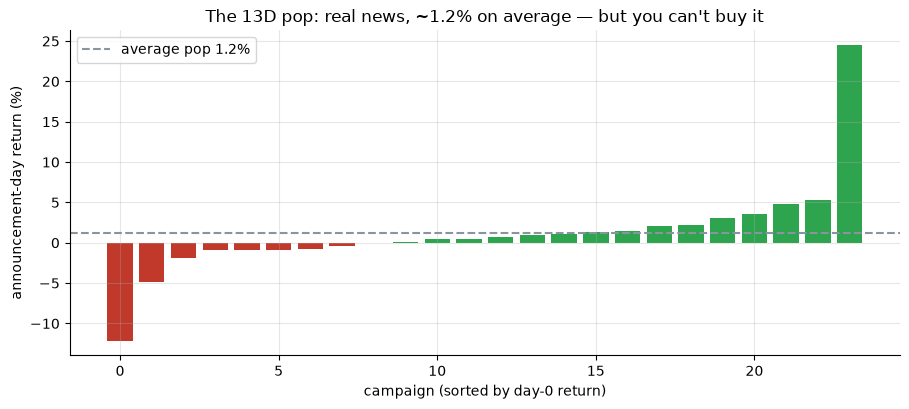

announcement pop: mean 1.22%  (positive 62% of the time)


In [2]:
if HAVE_REAL:
    pops = st.announcement_pops(PRICES, TBL)
    pm = pops.mean()*100
else:
    pops = np.array([R['pop'][1]/100]); pm = R['pop'][1]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
order = np.argsort(pops)
cols = [GREEN if p > 0 else RED for p in pops[order]]
ax.bar(range(len(pops)), pops[order]*100, color=cols)
ax.axhline(pm, c=GREY, ls='--', label=f'average pop {pm:.1f}%')
ax.set_xlabel('campaign (sorted by day-0 return)'); ax.set_ylabel('announcement-day return (%)')
ax.set_title(f'The 13D pop: real news, ~{pm:.1f}% on average — but you can\'t buy it'); ax.legend()
plt.tight_layout(); plt.show()
print(f'announcement pop: mean {pm:.2f}%  (positive { (pops>0).mean()*100:.0f}% of the time)')

A modest **+1.2%** average pop, up more often than not — real news. But it's the move *before* you can act, so it isn't a trade. The real question: what happens *after* you can buy?

**The drift you can actually buy.** Buy one day after the filing, hold, and measure the return *above the market* (target − SPY). Here it is at 1, 3 and 6 months, with the break-even line at zero.

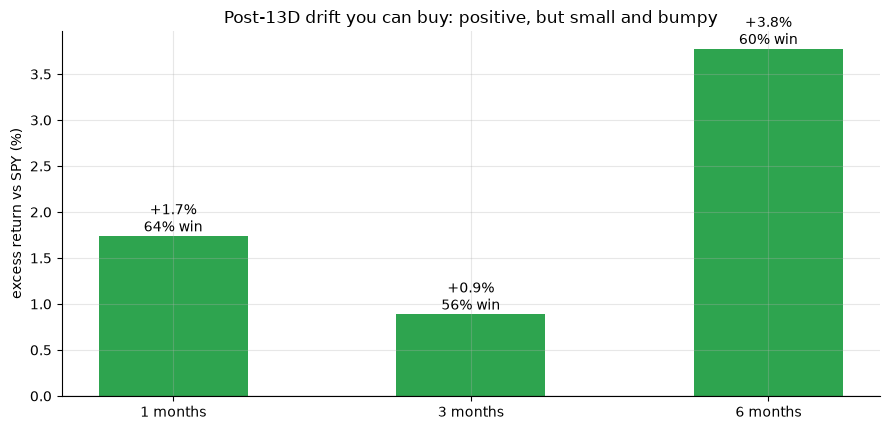

mean excess drift vs SPY: {'1m': '+1.7%', '3m': '+0.9%', '6m': '+3.8%'}


In [3]:
hs = [1, 3, 6]
if HAVE_REAL:
    means = [st.summarize(PRICES, TBL, m)['mean_excess']*100 for m in hs]
    wins  = [st.summarize(PRICES, TBL, m)['win_rate']*100 for m in hs]
else:
    means = [R['h1'][2], R['h3'][2], R['h6'][2]]
    wins  = [R['h1'][4], R['h3'][4], R['h6'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x, means, .5, color=GREEN)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('excess return vs SPY (%)')
ax.set_title('Post-13D drift you can buy: positive, but small and bumpy')
for i,(mn,w) in enumerate(zip(means,wins)):
    ax.annotate(f'{mn:+.1f}%\n{w:.0f}% win',(i,mn),ha='center',va='bottom' if mn>=0 else 'top')
plt.tight_layout(); plt.show()
print('mean excess drift vs SPY:', {f'{m}m': f'{v:+.1f}%' for m,v in zip(hs,means)})

Positive everywhere — the folklore points the right way. But look at the *shape*: **+1.7%** at one month, then it **shrinks** to **+0.9%** at three months, then jumps to **+3.8%** at six. A real, steady drift doesn't wobble like that — this is a small number bouncing around inside its own noise.

**Could random days look this good?** The honest test: for each campaign, compare buying on the 13D to buying the *same stock* on a **random** date. Do it thousands of times and see where the real 13D basket lands.

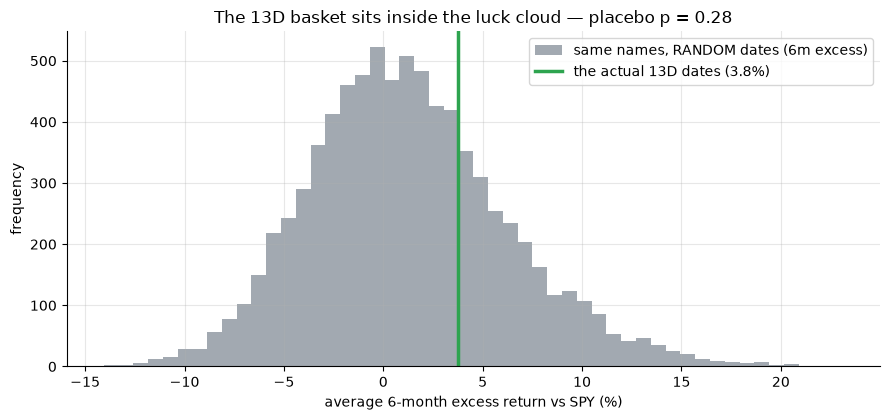

a random-date basket on the same names matches/beats the 13D 28% of the time


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PRICES, TBL, 6, n_draws=8000)
    obs = pl['obs_mean']*100; pmean = pl['placebo_mean']*100; pval = pl['p_value']
    # rebuild the placebo cloud for the picture
    spy = PRICES['SPY'].dropna(); h = st.TRADING_DAYS[6]; pools=[]
    for _, r in TBL.iterrows():
        s = PRICES[r['ticker']].dropna(); common = s.index.intersection(spy.index)
        sc = s.reindex(common).values; sp = spy.reindex(common).values
        if len(common) > h+2:
            pool = (sc[h:]/sc[:-h]-1) - (sp[h:]/sp[:-h]-1)
            pools.append(pool[np.isfinite(pool)])
    rng = np.random.default_rng(390)
    draws = np.array([np.mean([p[rng.integers(0,len(p))] for p in pools]) for _ in range(8000)])
else:
    obs = R['h6'][2]; pmean = 0.0; pval = R['h6'][6]
    rng = np.random.default_rng(390); draws = rng.normal(0, 0.04, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label='same names, RANDOM dates (6m excess)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual 13D dates ({obs:.1f}%)')
ax.set_xlabel('average 6-month excess return vs SPY (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The 13D basket sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random-date basket on the same names matches/beats the 13D {pval*100:.0f}% of the time')

The green line — the real 13D dates — falls **inside** the grey cloud of random draws. About **28%** of random-date baskets (on the *same* famous names) do as well or better. In plain terms: **buying these stocks on the activist's filing day is barely different from buying them on any random day.** The magic was in *which names you picked*, not *when*.

## 5 · The verdict

- **Signal — Weak.** The pop is real (**+1.2%**) and the drift is positive (**+3.8%** at 6m), but it's small, bumpy across horizons, statistically insignificant, and **carried by a few mega-caps**. Real as lore, weak as edge.
- **Tradability — Fragile.** Even granting the bump, **25 rare events** with an excess return inside the noise can't be a strategy you allocate to. Costs aren't the problem — significance is.
- **Free lunch? — Busted.** "Buy the 13D and ride the activist" is **survivorship**: a basket of legends *looks* like a free ride, but the leg you can actually trade matches random dates on the same names.

## 6 · Could you actually trade it? — costs aren't the problem

Suppose you ignored the statistics and ran it anyway. Trading costs are tiny on a multi-month hold — so it's *not* cost that kills this. Here's gross vs net of a 10-bps round-trip; they're almost on top of each other.

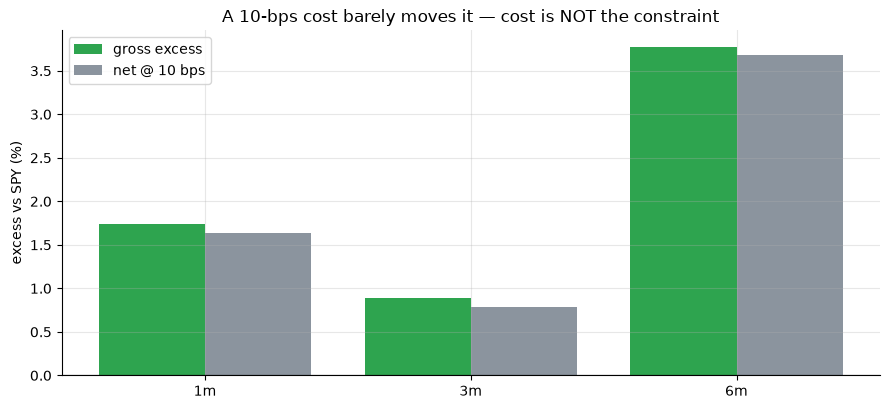

costs shave only ~0.1pp off a multi-month hold; the binding problem is significance, not cost


In [5]:
if HAVE_REAL:
    g = [st.net_of_costs(PRICES, TBL, m, 10.0)['gross_mean']*100 for m in [1,3,6]]
    nv = [st.net_of_costs(PRICES, TBL, m, 10.0)['net_mean']*100 for m in [1,3,6]]
else:
    g = [R['net'][0][1], R['net'][1][1], R['net'][2][1]]
    nv = [R['net'][0][2], R['net'][1][2], R['net'][2][2]]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(x-.2, g, .4, color=GREEN, label='gross excess')
ax.bar(x+.2, nv, .4, color=GREY, label='net @ 10 bps')
ax.set_xticks(x); ax.set_xticklabels(['1m','3m','6m']); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('excess vs SPY (%)'); ax.set_title('A 10-bps cost barely moves it — cost is NOT the constraint')
ax.legend(); plt.tight_layout(); plt.show()
print('costs shave only ~0.1pp off a multi-month hold; the binding problem is significance, not cost')

The bars are almost identical: a 10-bps round-trip shaves about **0.1 point** off a months-long hold. So costs are *not* what sinks this. What sinks it is that the gross excess is **statistically indistinguishable from random dates** on the same names — and it only fires when an Icahn-scale name shows up. You can't build a portfolio around a rare event whose payoff is inside the noise.

## 7 · Going further 🚪

- **The pop is the real story.** Large academic samples (Brav et al., 2008) find a genuine **+7–8%** abnormal jump *around* the filing — but it's concentrated in the announcement window you can't trade, and the post-filing alpha is concentrated in targets that get **bought out**. The average outside-buyer drift is thin.
- **Build a real 13D panel.** Swap our 25 famous names for *every* 13D on EDGAR (including the forgotten ones) and the survivorship tilt that helps the claim disappears — the drift should get *weaker*, not stronger.
- **Condition on the outcome.** Split campaigns into "ended in a sale" vs "fizzled"; the lore lives almost entirely in the takeover tail.

*Think the 13D drift beats the market by more than luck? Build the full filing panel, buy one day after each, race it against SPY, and show the basket landing **outside** the random-date cloud — then we'll talk.*